Step 1 - Import Required Libraries.
         Load Python packages for data manipulation, visualization,            preprocessing, modeling, and evaluation.

In [1]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)


Step 2 - Load Training and Test Datasets.
         Import train.csv, test.csv, and sample_submission.csv into            Pandas DataFrames.

In [2]:
# Step 2: Load Training and Test Datasets

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
submission = pd.read_csv("sample_submission.csv")

print(train.shape)
print(test.shape)

train.head()


(20758, 18)
(13840, 17)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


Step3 -  Perform Initial Data Exploration (EDA).
         Inspect dataset structure, data types, missing values, and            summary statistics.

In [3]:
# Step 3: Perform Initial Data Exploration (EDA)

train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

,id,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,20758.00000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,10378.50000,23.841804,1.700245,87.887768,2.445908,2.761332,2.029418,0.981747,0.616756
std,5992.46278,5.688072,0.087312,26.379443,0.533218,0.705375,0.608467,0.838302,0.602113
min,0.00000,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,5189.25000,20.000000,1.631856,66.000000,2.000000,3.000000,1.792022,0.008013,0.000000
50%,10378.50000,22.815416,1.700000,84.064875,2.393837,3.000000,2.000000,1.000000,0.573887
75%,15567.75000,26.000000,1.762887,111.600553,3.000000,3.000000,2.549617,1.587406,1.000000
max,20757.00000,61.000000,1.975663,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000


Step 4 - Analyze Feature Relationships with Correlation Heatmap.
         Examine correlations among numerical variables to understand          relationships and potential predictors.

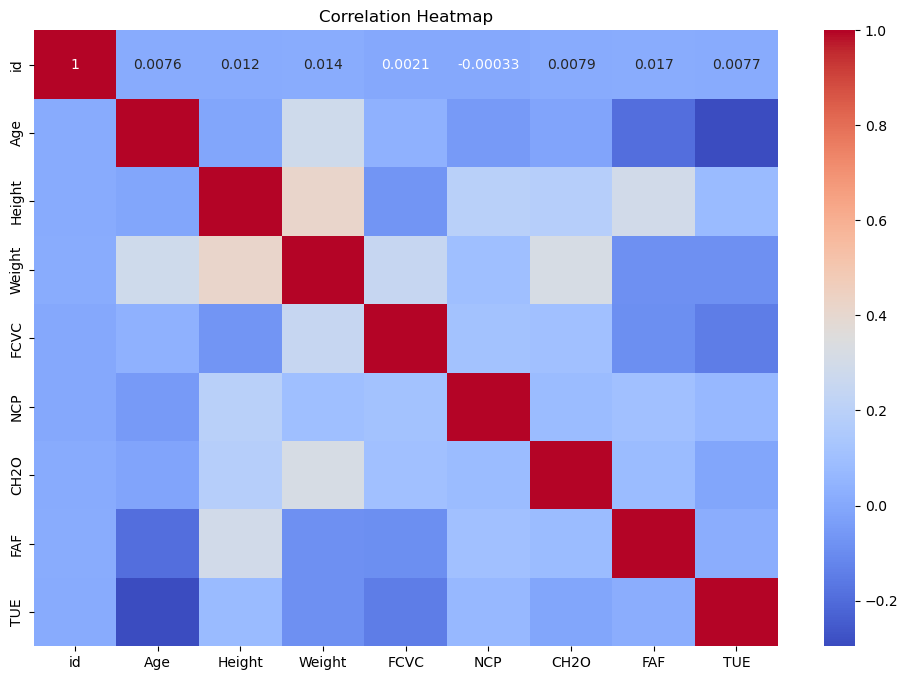

In [4]:
# Step 4 Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(train.corr(numeric_only=True),
cmap='coolwarm',
annot=True)
plt.title("Correlation Heatmap")

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 1 DECISION TREE SUBMISSION/reports/figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

Step 5 - Visualize Feature Distributions.
         Generate histograms to examine the distribution of numerical          variables.

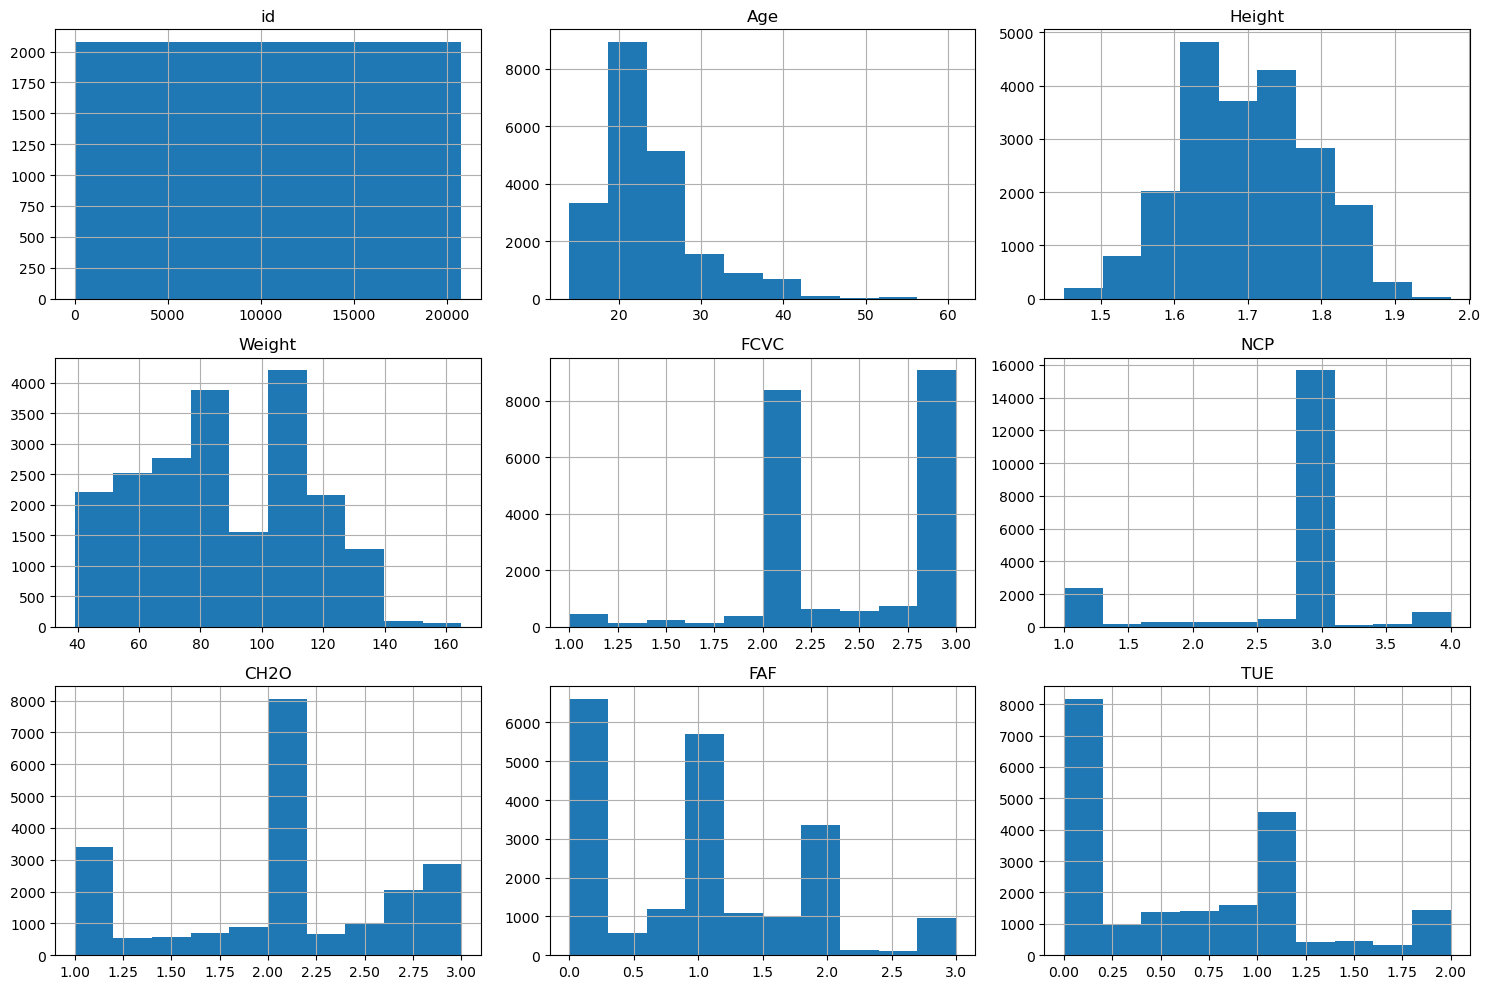

In [5]:
# Step 5: Visualize Feature Distributions

train.hist(figsize=(15,10))
plt.tight_layout()

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 1 DECISION TREE SUBMISSION/reports/figures/feature_distributions.png", dpi=300, bbox_inches="tight")

plt.show()

Step 6 -  Visualize Target Class Distribution.
          Check the balance of obesity categories before modeling.

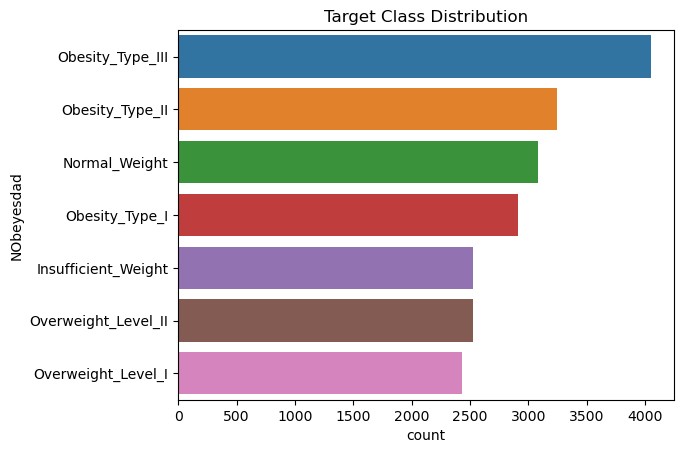

In [6]:
# Step 6: Visualize Target Class Distribution

sns.countplot(
    y='NObeyesdad',
    data=train,
    order=train['NObeyesdad'].value_counts().index
)

plt.title("Target Class Distribution")

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 1 DECISION TREE SUBMISSION/reports/figures/class_distribution.png", dpi=300, bbox_inches="tight")

plt.show()


Step 7 -  Encode Categorical Variables and Prepare Features.
          Convert categorical variables into numeric format and                 separate features from the target variable.

In [7]:
# Step 7: Encode Categorical Variables and Prepare Features

combined = pd.concat([train.drop("NObeyesdad", axis=1), test])

categorical_cols = combined.select_dtypes(include=["object"]).columns

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col])
    encoders[col] = le

X_train_full = combined.iloc[:len(train)]
X_test = combined.iloc[len(train):]

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(train["NObeyesdad"])


Step 8 - Split Data into Training and Validation Sets.
         Create training and validation datasets for model                    development and testing.

In [8]:
# Step 8: Split Data into Training and Validation SetsTrain/Test Split

X_train, X_valid, y_train, y_valid = train_test_split(
X_train_full,
y,
test_size=0.20,
random_state=42,
stratify=y
)

Step 9 -  Train the Decision Tree Classifier.
          Build the Decision Tree model using the training data.

In [9]:
# Step 9: Train the Decision Tree Classifier

dt_model = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

dt_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=8, random_state=42)

Step 10 - Generate Validation Predictions.
          Predict obesity classes on the validation dataset and                 calculate model accuracy.

In [10]:
# Step #10: Generate Validation Predictions

pred_dt = dt_model.predict(X_valid)

accuracy_dt = accuracy_score(y_valid, pred_dt)

print("Accuracy:", accuracy_dt)


Accuracy: 0.8694605009633911


Step 11 -  Evaluate Model Using a Confusion Matrix.
           Assess classification performance and identify prediction            errors by class.

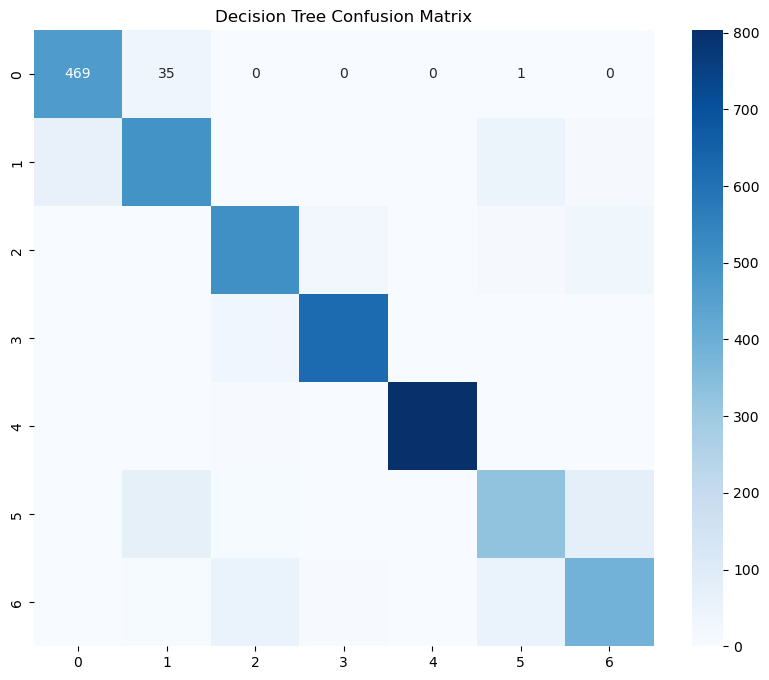

In [11]:
# Step 11: Evaluate Model Using a Confusion Matrix

plt.figure(figsize=(10, 8))
sns.heatmap(
    confusion_matrix(y_valid, pred_dt),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 1 DECISION TREE SUBMISSION/reports/figures/confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()


Step 12 -  Visualize the Decision Tree Structure.
           Display the learned decision rules and tree branches.

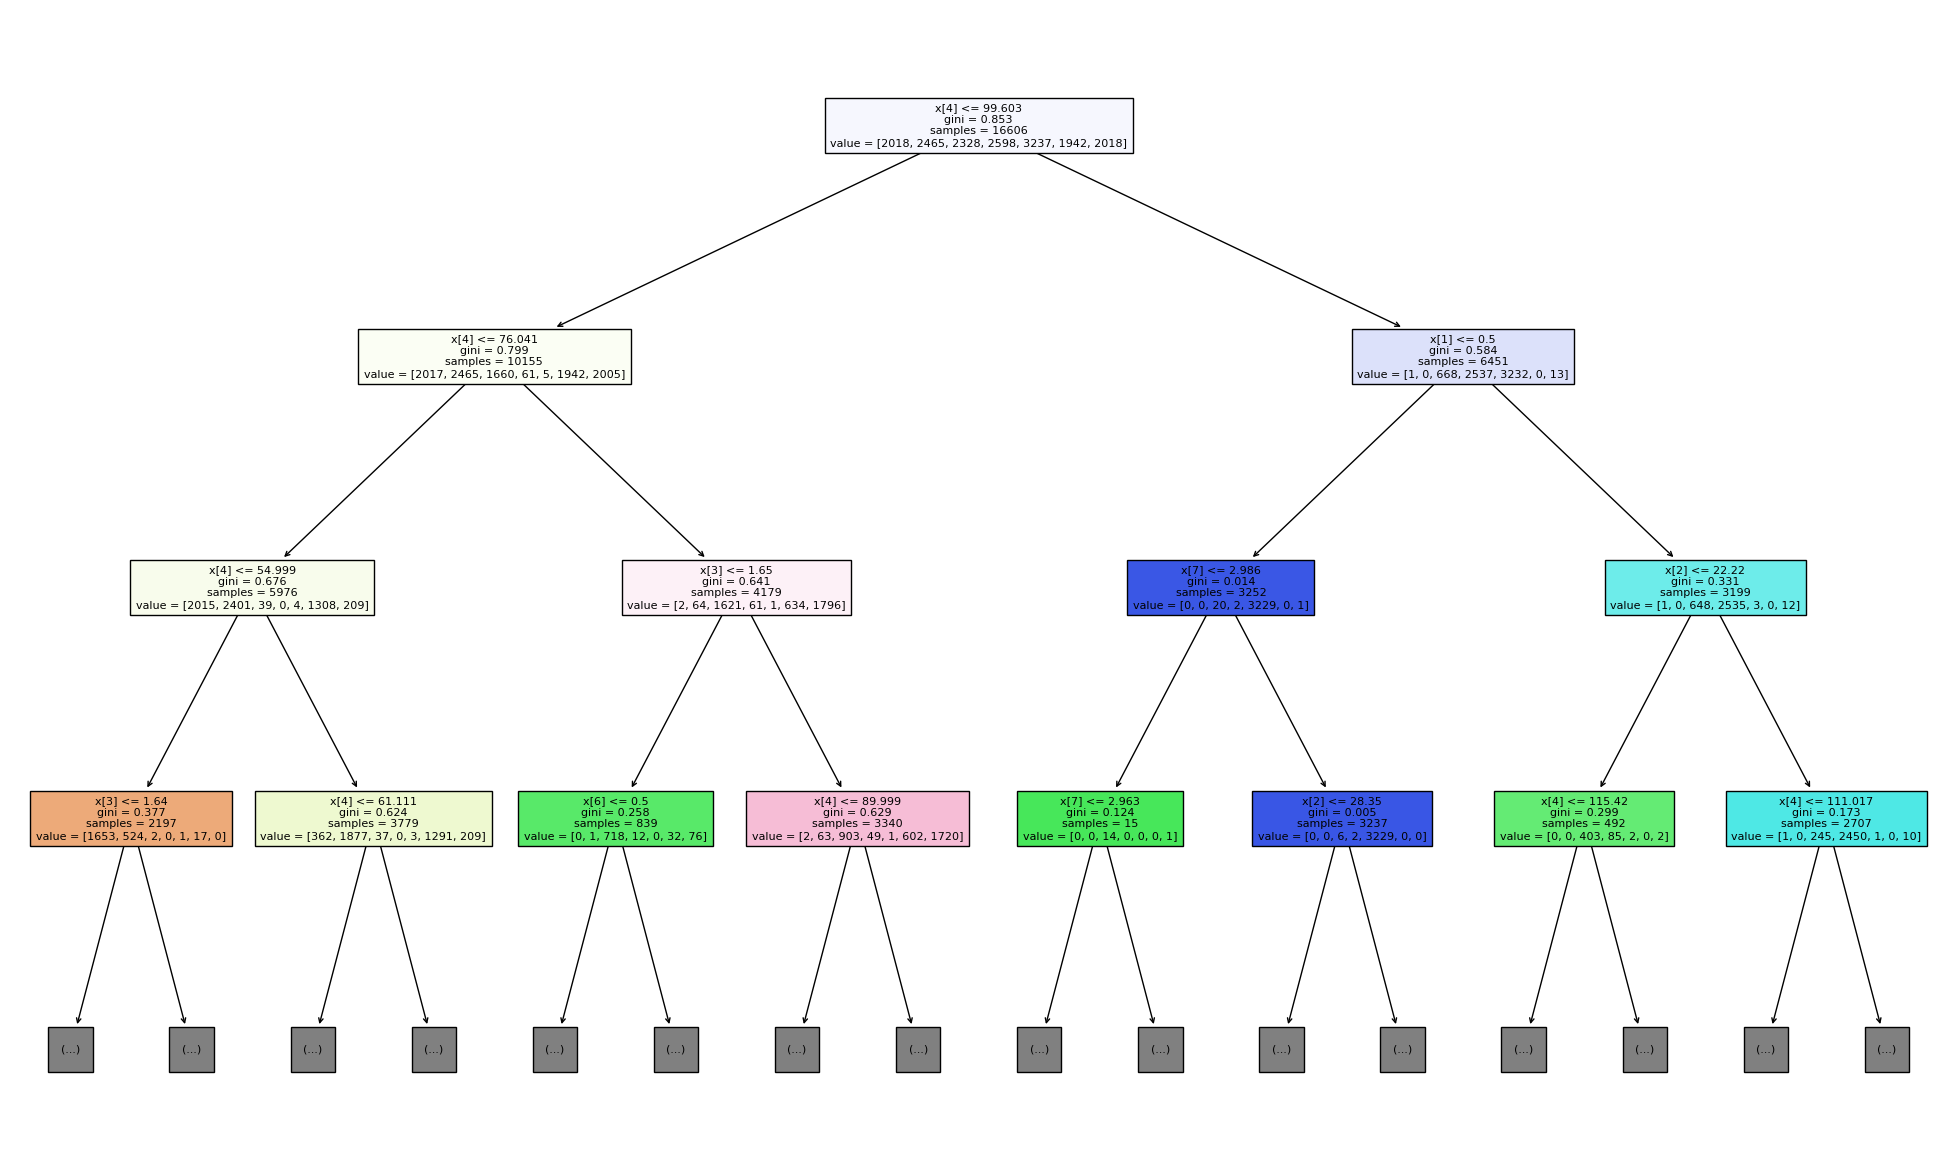

In [12]:
# Step 12: Visualize the Decision Tree Structure
plt.figure(figsize=(25, 15))

plot_tree(
    dt_model,
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 1 DECISION TREE SUBMISSION/reports/figures/decision_tree_structure.png", dpi=300, bbox_inches="tight")

plt.show()


Step 13 - Analyze Feature Importance.
          Identify the most influential variables affecting                     predictions.

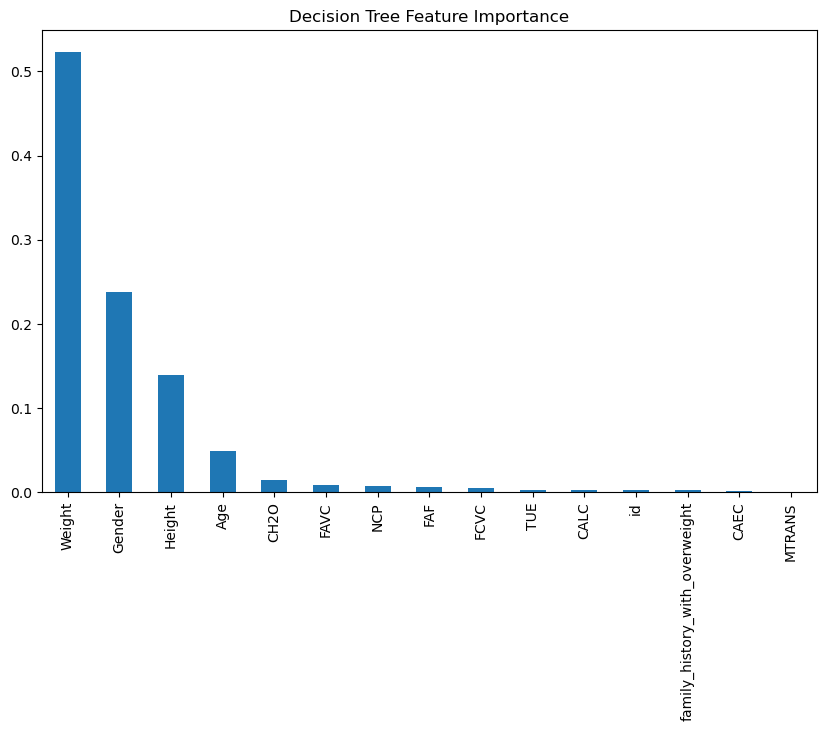

In [13]:
#Step 13: Analyze Feature Importance

importance = pd.Series(
    dt_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.head(15).plot(kind='bar')
plt.title("Decision Tree Feature Importance")

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 1 DECISION TREE SUBMISSION/reports/figures/decision_tree_feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()


Step 14 - Generate Final Test Predictions & Create Kaggle Submission #1. 
          Apply the trained model to the unseen test dataset.
          Save predictions in the required submission format for               competition upload.

In [14]:
#Step 14: Generate Final Test Predictions & Create Kaggle Submission #1


test_preds = dt_model.predict(X_test)

submission['NObeyesdad'] = target_encoder.inverse_transform(test_preds)

submission.to_csv(
    "submission_decision_tree.csv",
    index=False
)

submission.head()


,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_II
4,20762,Obesity_Type_III
